In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style
# Custom color palette (expanded)
COLORS = [
    '#F0B429',  # Yellow
    '#C87D0E',  # Orange
    '#D81B7A',  # Magenta
    '#7B2D8B',  # Deep Purple
    '#9B8BB4',  # Lavender
    '#E85D9A',  # Soft Pink (compliments Magenta)
    '#5B1F7A',  # Dark Violet (deeper than purple)
    '#F7D26A',  # Light Gold (lighter yellow)
    '#B5478A',  # Dusty Rose (between pink & purple)
    '#C9A0DC',  # Wisteria (lighter lavender)
]

sns.set_palette(COLORS)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load cleaned data
df = pd.read_csv('C:/churn_project/outputs/cleaned_data.csv')
print("Data loaded ✅")
print("Shape:", df.shape)

Data loaded ✅
Shape: (7043, 20)


Overall Churn Rate: 26.54%


C:\Users\aasth\AppData\Local\Temp\ipykernel_3052\1749752006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=palette)


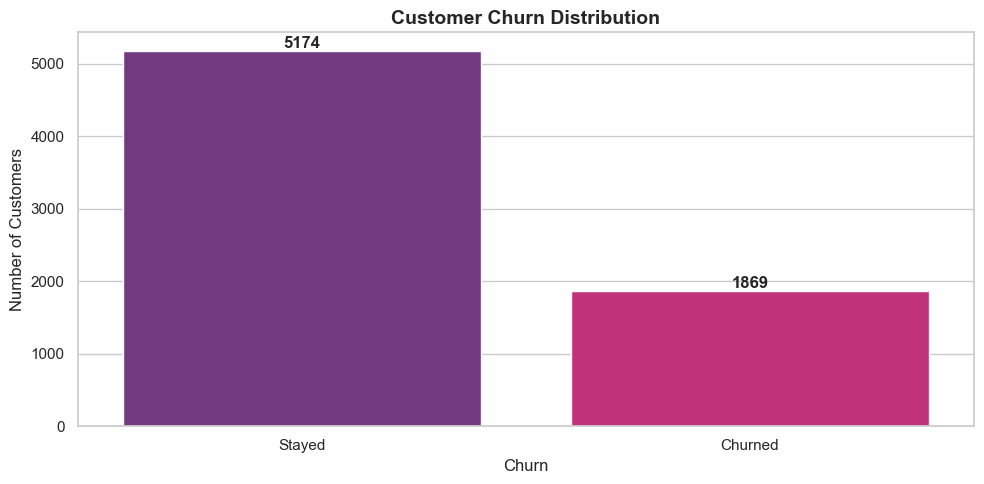

Chart saved ✅


In [7]:
# Your custom palette
palette = ['#7B2D8B', '#D81B7A']  # Purple = Stayed, Pink = Churned

# Calculate churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Plot
ax = sns.countplot(x='Churn', data=df, palette=palette)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('C:/churn_project/outputs/churn_distribution.png', dpi=150)
plt.show()

print("Chart saved ✅")

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


C:\Users\aasth\AppData\Local\Temp\ipykernel_3052\420222265.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Contract', y='Churn', data=df,
C:\Users\aasth\AppData\Local\Temp\ipykernel_3052\420222265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Contract', y='Churn', data=df,


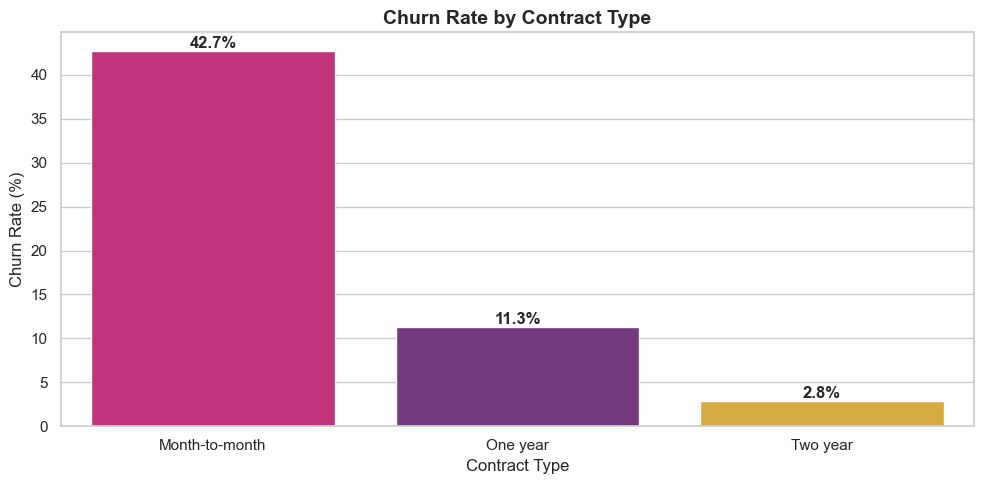

Chart saved ✅


In [8]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print("Churn Rate by Contract Type:")
print(contract_churn.round(2))

# Plot
ax = sns.barplot(x='Contract', y='Churn', data=df, 
                 palette=['#D81B7A', '#7B2D8B', '#F0B429'],
                 estimator=lambda x: sum(x)/len(x)*100,
                 ci=None)

# Add % labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('C:/churn_project/outputs/churn_by_contract.png', dpi=150)
plt.show()

print("Chart saved ✅")

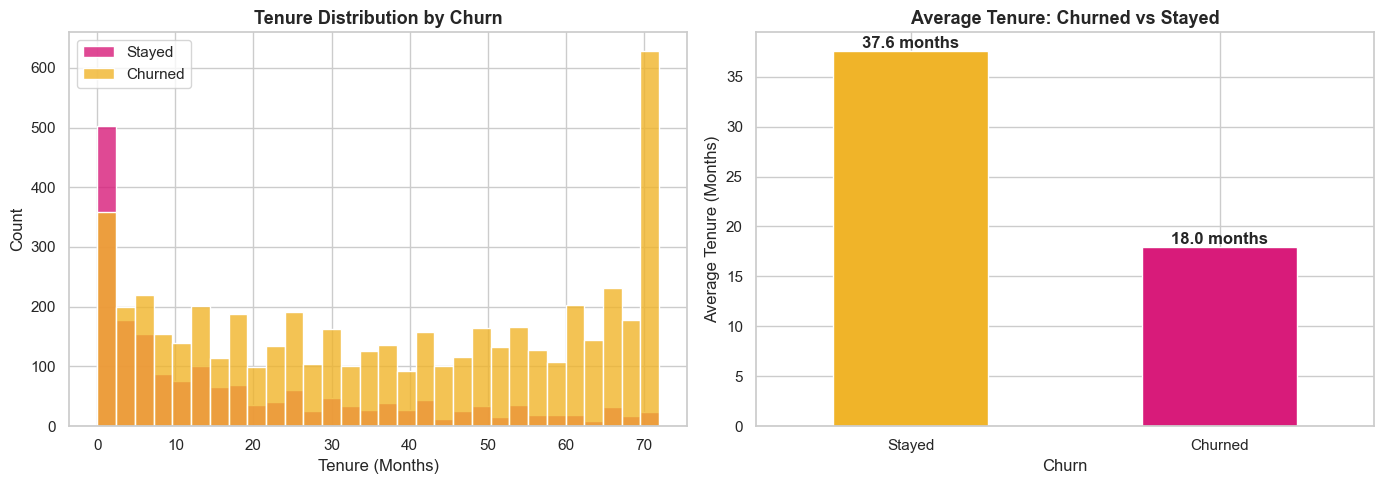

Chart saved ✅


In [11]:
# Plot churn rate across tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Tenure distribution by churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#F0B429', '#D81B7A'], ax=axes[0], alpha=0.8)
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend(labels=['Stayed', 'Churned'])

# Chart 2 - Average tenure for churned vs stayed
avg_tenure = df.groupby('Churn')['tenure'].mean()
ax2 = avg_tenure.plot(kind='bar', ax=axes[1], 
                      color=['#F0B429', '#D81B7A'], 
                      edgecolor='white', width=0.5)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f} months',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_title('Average Tenure: Churned vs Stayed', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[1].set_ylabel('Average Tenure (Months)')

plt.tight_layout()
plt.savefig('C:/churn_project/outputs/churn_by_tenure.png', dpi=150)
plt.show()

print("Chart saved ✅")

Average Monthly Charges:
Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64


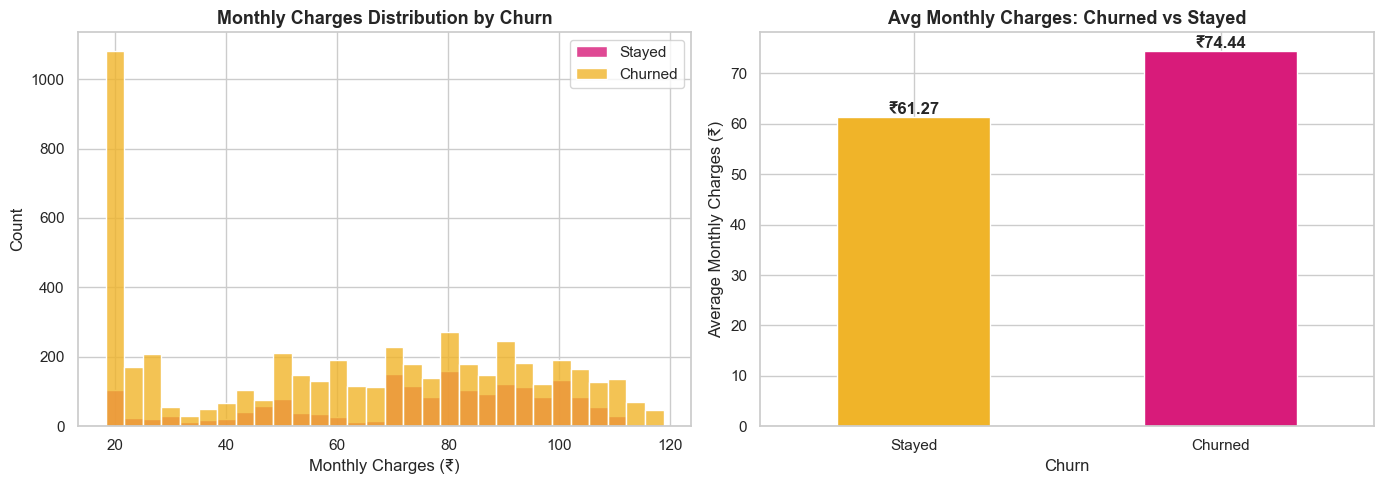

Chart saved ✅


In [13]:
# Chart 1 - Monthly charges distribution by churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             palette=['#F0B429', '#D81B7A'], ax=axes[0], alpha=0.8)
axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges (₹)')
axes[0].set_ylabel('Count')
axes[0].legend(labels=['Stayed', 'Churned'])

# Chart 2 - Average monthly charges for churned vs stayed
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("Average Monthly Charges:")
print(avg_charges.round(2))

ax2 = avg_charges.plot(kind='bar', ax=axes[1],
                       color=['#F0B429', '#D81B7A'],
                       edgecolor='white', width=0.5)

for p in axes[1].patches:
    axes[1].annotate(f'₹{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_title('Avg Monthly Charges: Churned vs Stayed', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[1].set_ylabel('Average Monthly Charges (₹)')

plt.tight_layout()
plt.savefig('C:/churn_project/outputs/churn_by_charges.png', dpi=150)
plt.show()

print("Chart saved ✅")


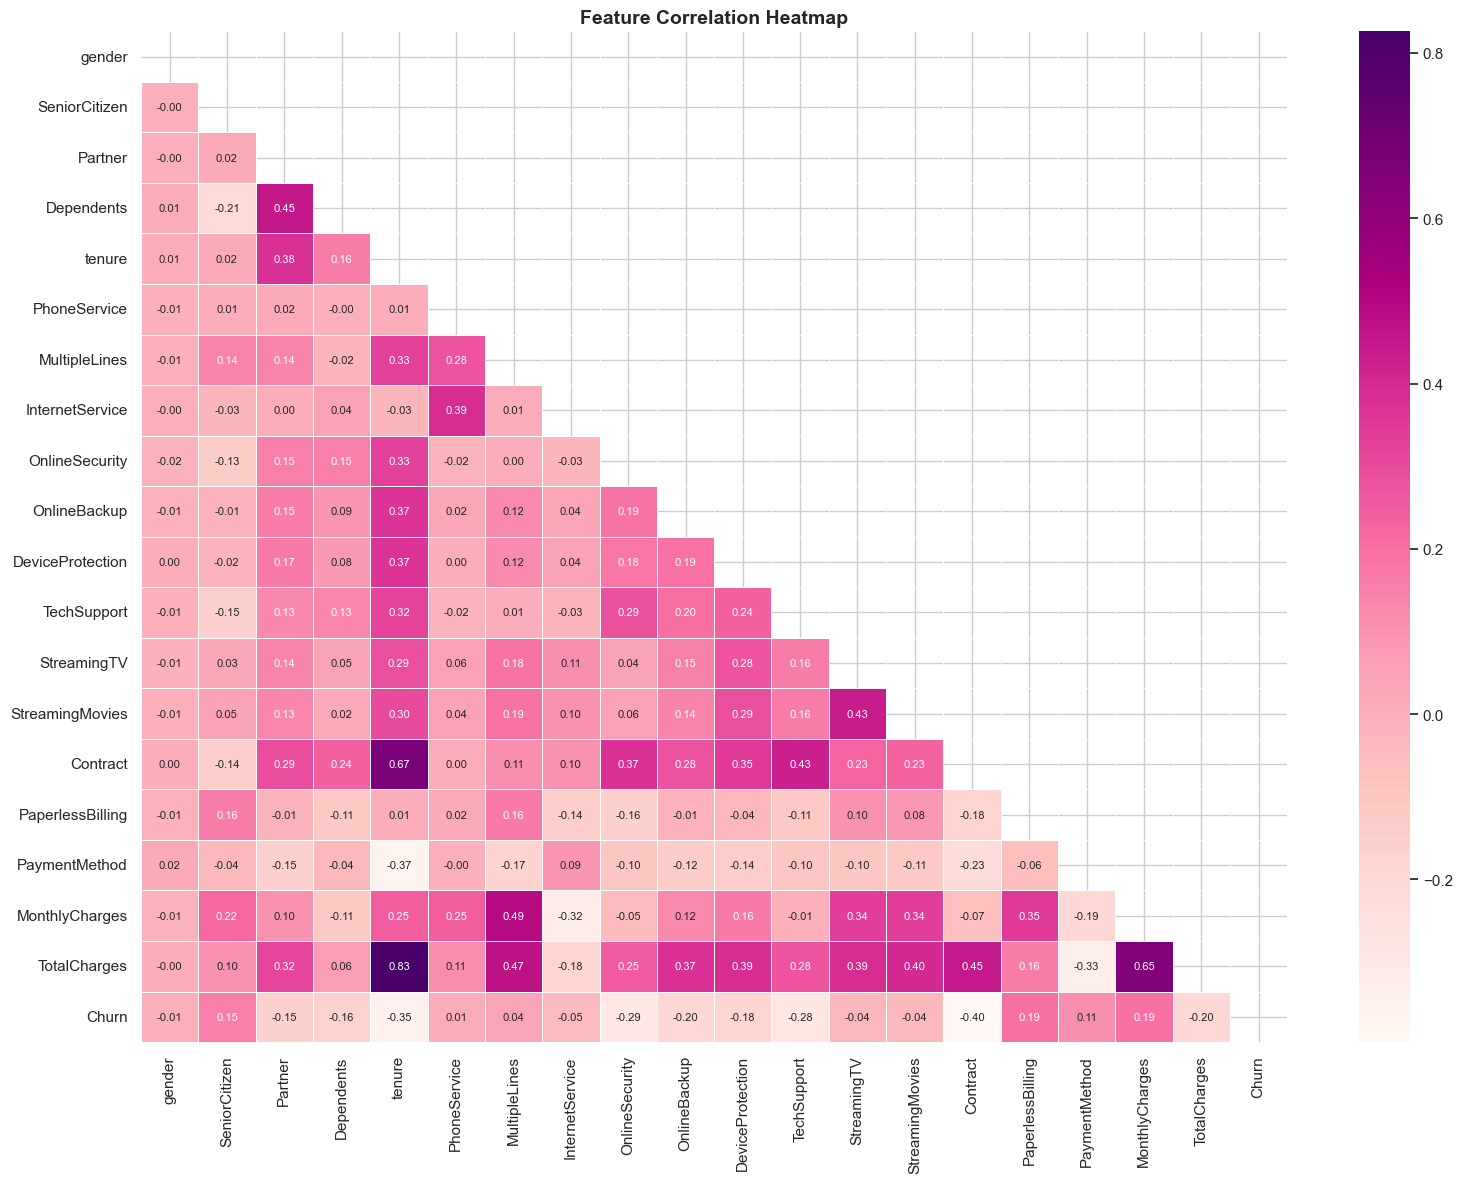

Chart saved ✅


In [14]:
# Encode categorical columns for correlation
df_encoded = df.copy()

# Convert all Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0, 
                                           'No phone service': 0})

# Encode other categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['gender', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaymentMethod']

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Plot heatmap
plt.figure(figsize=(16, 12))
mask = np.zeros_like(df_encoded.corr())
mask[np.triu_indices_from(mask)] = True  # Hide upper triangle (redundant)

sns.heatmap(df_encoded.corr(), 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdPu',
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/churn_project/outputs/correlation_heatmap.png', dpi=150)
plt.show()

print("Chart saved ✅")